# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Loading the dataset

In [2]:
#creating database connection
conn = sqlite3.connect('inventory.db')

#fetching vendor summary data
df = pd.read_sql("""
SELECT * 
FROM vendor_sales_summary
""", conn)
df

,VendorNumber,VendorName,Brand,Description,Volume,ActualPrice,PurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesAvgPrice,TotalSalesQuantity,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,1750.00,36.99,26.27,145080,3811251.60,35.92,142049,5101919.51,260999.20,68601.68,1290667.91,25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,1750.00,28.99,23.19,164038,3804041.22,30.07,160247,4819073.49,294438.66,144929.24,1015032.27,21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,1750.00,24.99,18.24,187407,3418303.68,24.25,187140,4538120.60,343854.07,123780.22,1119816.92,24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,1750.00,22.99,16.17,201682,3261197.94,22.33,200412,4475972.88,368242.80,257032.07,1214774.94,27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,1750.00,29.99,21.89,138109,3023206.01,31.09,135838,4223107.62,249587.83,257032.07,1199901.61,28.41,0.98,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,750.00,4.99,1.32,2,2.64,3.19,5,15.95,0.55,27100.41,13.31,83.45,2.50,6.04
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,50.00,0.49,0.39,6,2.34,0.49,134,65.66,7.04,50293.62,63.32,96.44,22.33,28.06
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,50.00,0.99,0.74,2,1.48,0.99,2,1.98,0.10,14069.87,0.50,25.25,1.00,1.34
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,200.00,1.99,1.47,1,1.47,1.99,72,143.28,15.12,257032.07,141.81,98.97,72.00,97.47


# Exploratory Data Analysis

- <strong>Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

- <strong>In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeeding with further analysis. 

In [3]:
# summmary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.00,10650.65,18753.52,2.00,3951.00,7153.00,9552.00,201359.00
Brand,10692.00,18039.23,12662.19,58.00,5793.50,18761.50,25514.25,90631.00
Volume,10692.00,847.36,664.31,50.00,750.00,750.00,750.00,20000.00
ActualPrice,10692.00,35.64,148.25,0.49,10.99,15.99,28.99,7499.99
PurchasePrice,10692.00,24.39,109.27,0.36,6.84,10.46,19.48,5681.81
TotalPurchaseQuantity,10692.00,3140.89,11095.09,1.00,36.00,262.00,1975.75,337660.00
TotalPurchaseDollars,10692.00,30106.69,123067.80,0.71,453.46,3655.47,20738.25,3811251.60
TotalSalesAvgPrice,10692.00,33.23,125.26,0.00,10.16,15.15,27.66,5799.99
TotalSalesQuantity,10692.00,3077.48,10952.85,0.00,33.00,261.00,1929.25,334939.00
TotalSalesDollars,10692.00,42239.07,167655.27,0.00,729.22,5298.05,28396.92,5101919.51


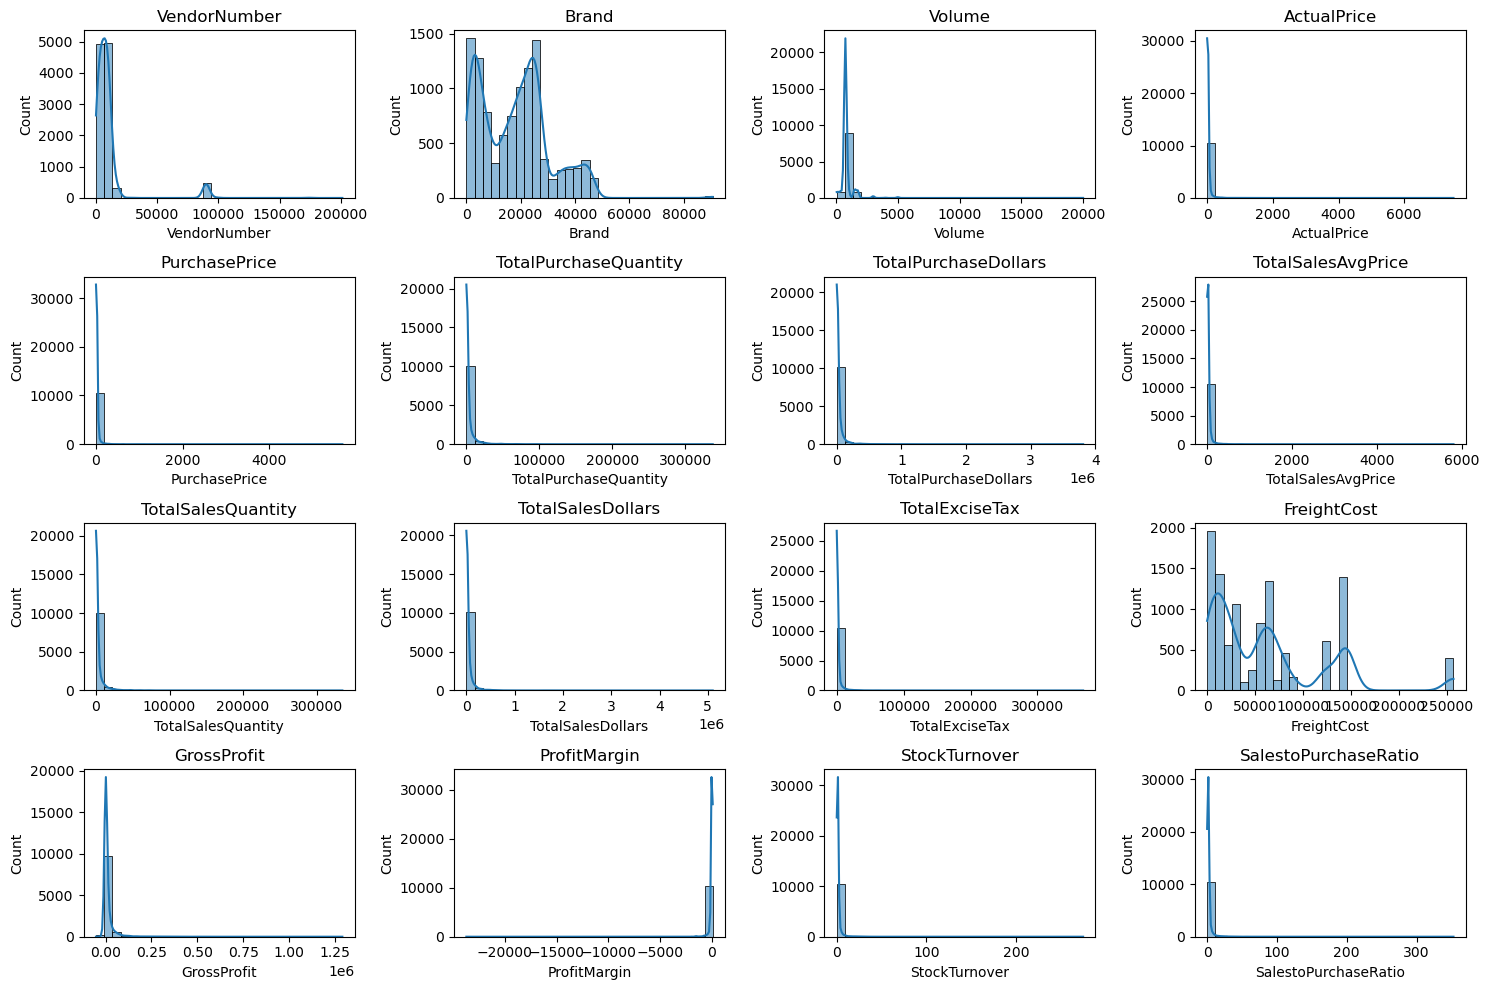

In [4]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # adjusting grid layout as needed
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

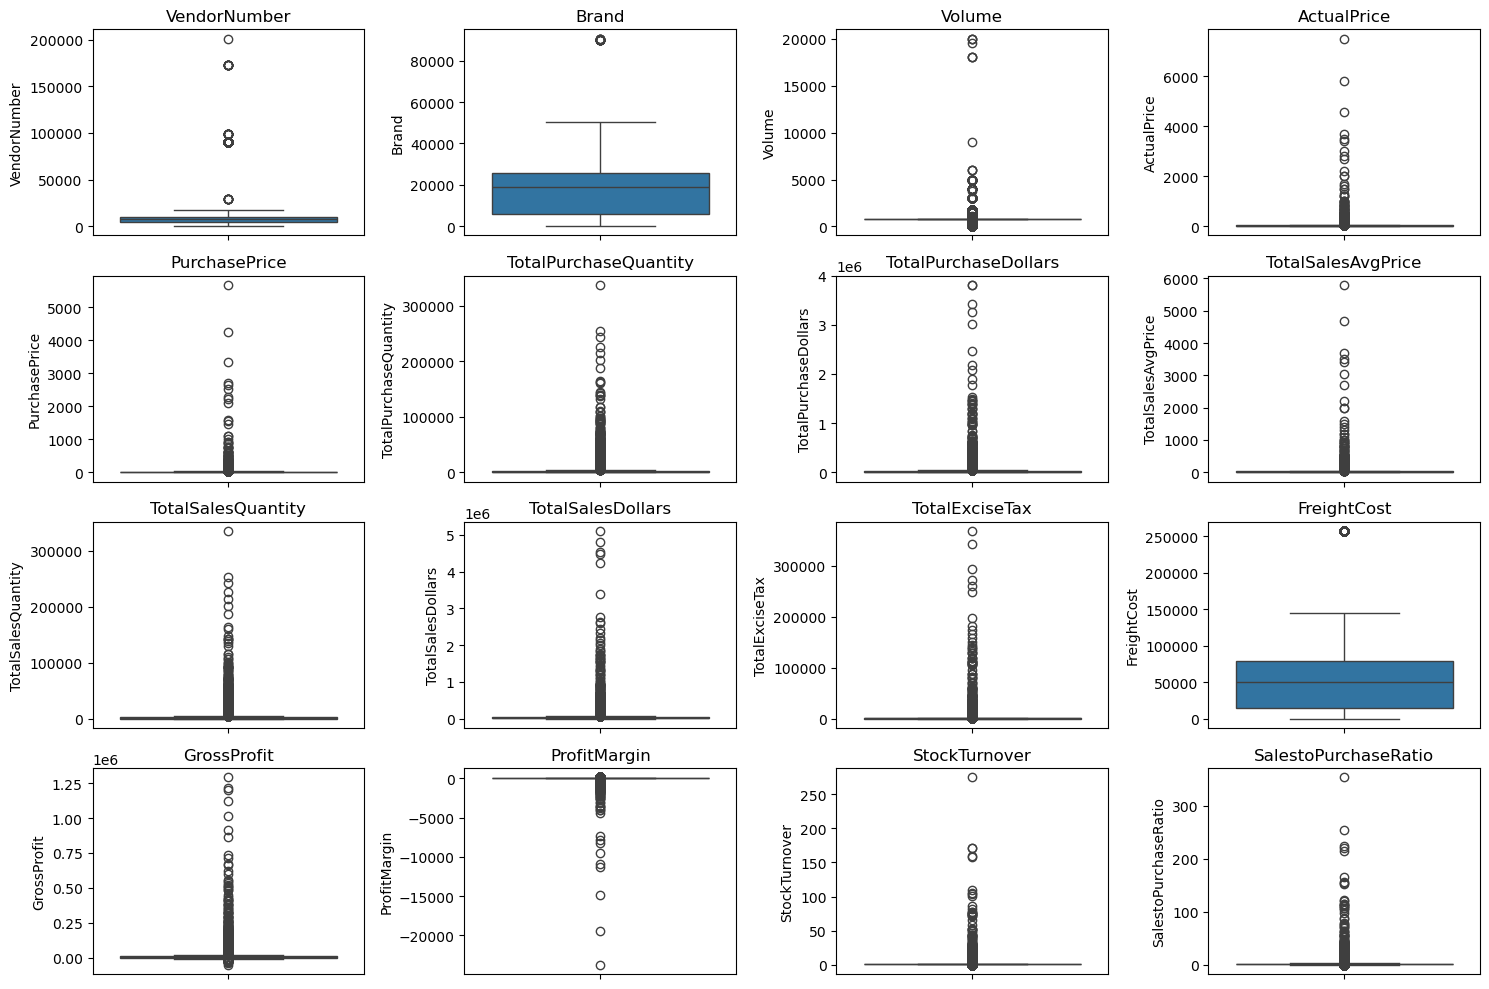

In [5]:
# Outlier Detection using Boxplots
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # adjusting grid layout as needed
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:

<strong> Negative & Zero Values:

 - Gross Profit: Minimumn values is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.

 - Profit Margin: Has a minimum -inf, which suggests cases where revenue is zero or even lower than costs.

 - Total Sales Quantity & Sales Dollars: Minimun values are 0, meaning some products were purchased but never sold. These could be slow-moving or absolute stock.

<strong> Outliers Indicated by High Standard Deviation:

- Purchase Price & Actual Price: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

- Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics insufficiencies or bulk shipments.

- Stock Turnover: Ranges from 0 to 274.5, implying some products sell really fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.   

In [6]:
# filtering the data by removing inconsistencies as per business requirements

df_2 = pd.read_sql("""
SELECT * 
FROM vendor_sales_summary
WHERE TotalSalesQuantity > 0
AND NOT (TotalSalesQuantity > TotalPurchaseQuantity)
AND ProfitMargin > -101
""", conn)

### The above filtrations were required because:

<strong> To improve the reliblility of the insights, the following data points were removed :
- **Excluded records with zero sales** because, without time-series data, we cannot determine whether the product is newly introduced or has been available for a while but is not selling.

- **Excluded records where total sales quantity is higher than total purchase quantity** because some of the sales may have come from older stock, which could make newly added products look less or more successful than they actually are.

- **Excluded records with a profit margin of -101% or lower** because such extreme losses may indicate (may vary business to business):
  - A newly introduced product which has just started selling, or
  - A large amount of unsold inventory, which businesses may simply clear out, discard, or return to the vendor rather than analyze further.

**Keeping such records could therefore lead to misleading conclusions about product and vendor performance.**

In [7]:
df_2

,VendorNumber,VendorName,Brand,Description,Volume,ActualPrice,PurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesAvgPrice,TotalSalesQuantity,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,1750.00,36.99,26.27,145080,3811251.60,35.92,142049,5101919.51,260999.20,68601.68,1290667.91,25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,1750.00,28.99,23.19,164038,3804041.22,30.07,160247,4819073.49,294438.66,144929.24,1015032.27,21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,1750.00,24.99,18.24,187407,3418303.68,24.25,187140,4538120.60,343854.07,123780.22,1119816.92,24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,1750.00,22.99,16.17,201682,3261197.94,22.33,200412,4475972.88,368242.80,257032.07,1214774.94,27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,1750.00,29.99,21.89,138109,3023206.01,31.09,135838,4223107.62,249587.83,257032.07,1199901.61,28.41,0.98,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6318,9815,WINE GROUP INC,26950,Firefly Ridge Chard,750.00,5.79,3.99,1,3.99,5.79,1,5.79,0.11,27100.41,1.80,31.09,1.00,1.45
6319,8673,STE MICHELLE WINE ESTATES,13344,Columbia Crest Two Vines Rsl,1500.00,5.29,3.57,1,3.57,5.29,1,5.29,0.22,15919.70,1.72,32.51,1.00,1.48
6320,4425,MARTIGNETTI COMPANIES,27934,Terruzzi & Puthod Vernaccia,750.00,4.99,3.37,1,3.37,4.99,1,4.99,0.11,144929.24,1.62,32.46,1.00,1.48
6321,6785,PALM BAY INTERNATIONAL INC,22161,Santa Rita Organic Svgn Bl,750.00,4.99,3.35,1,3.35,9.99,1,9.99,0.11,13605.41,6.64,66.47,1.00,2.98


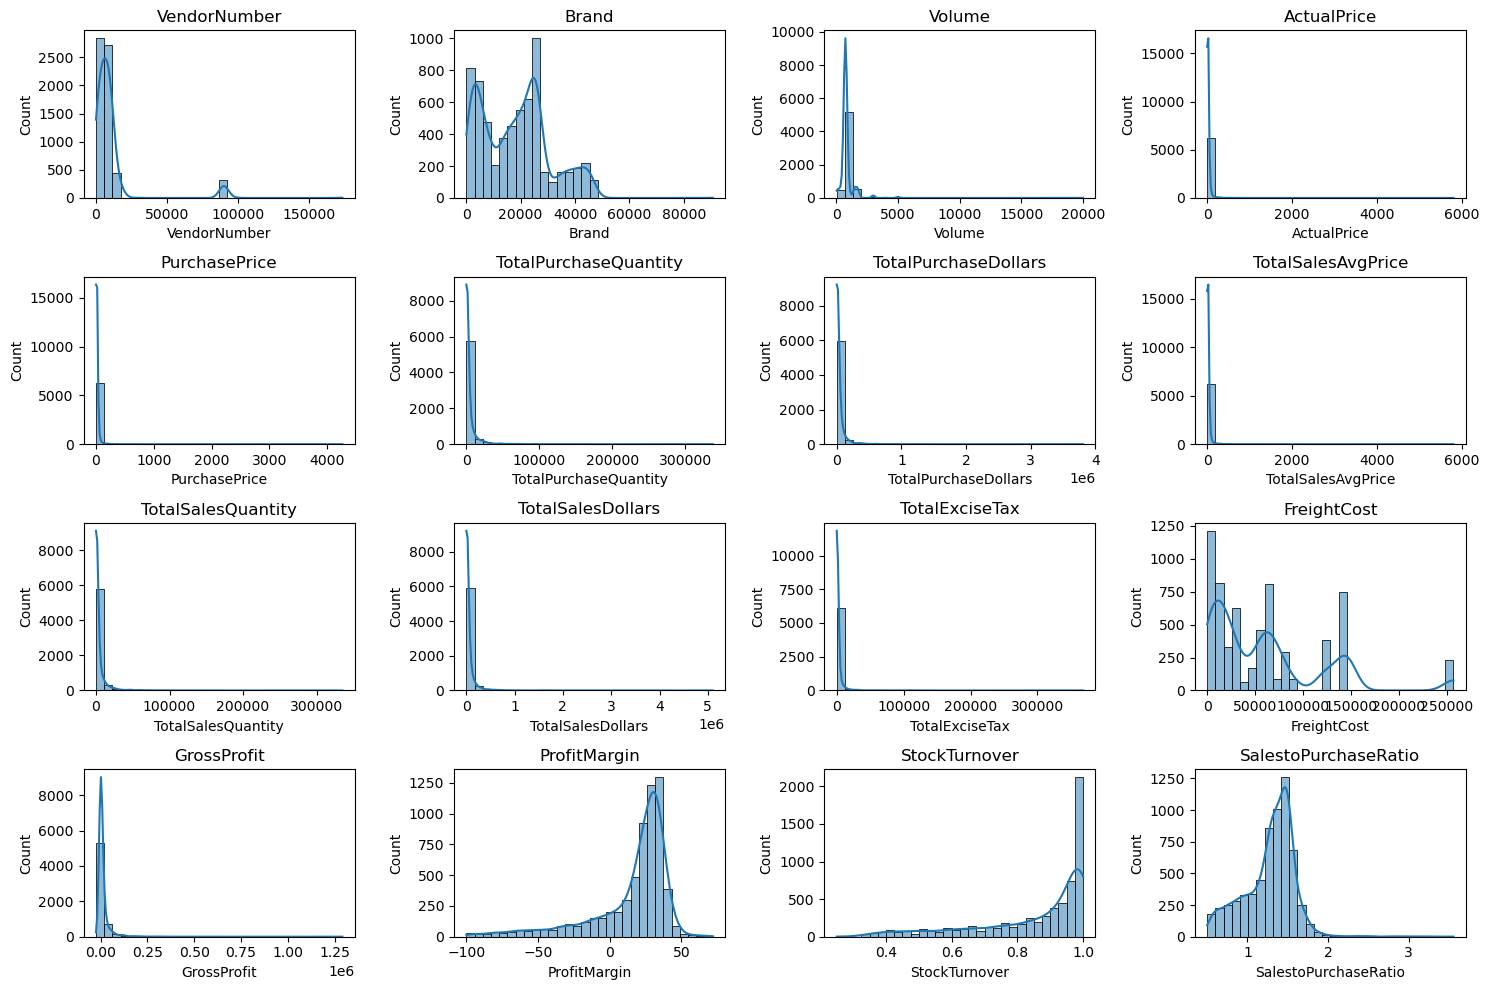

In [8]:
# Distribution Plots for Numerical Columns
numerical_cols = df_2.select_dtypes(include = np.number).columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # adjusting grid layout as needed
    sns.histplot(df_2[col], kde = True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

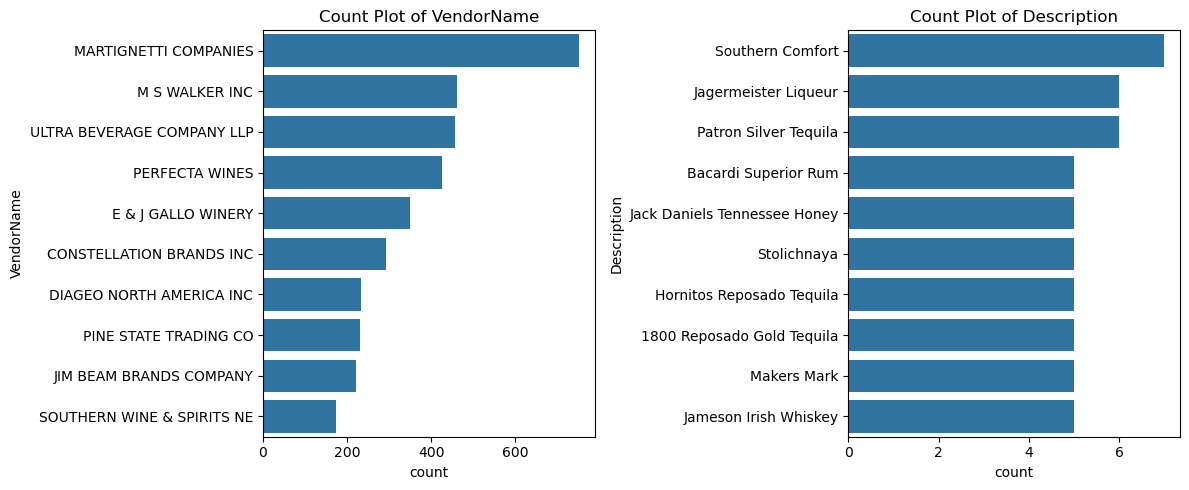

In [9]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize = (12, 5))
for i, col in enumerate(categorical_cols) :
    plt.subplot(1, 2, i+1)
    sns.countplot(y = df_2[col], order = df_2[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

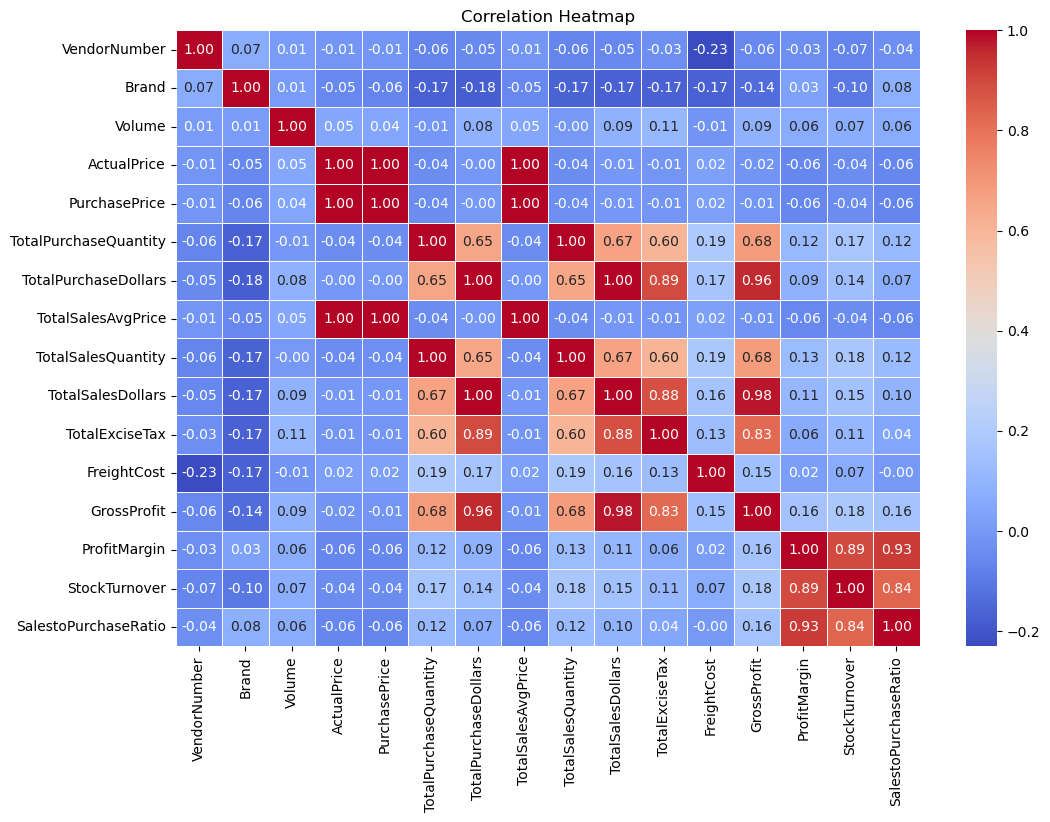

In [10]:
#correlation Heatmap
plt.figure(figsize = (12, 8))
correlation_matrix = df_2[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', linewidth = 0.5)
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights

- **PurchasePrice** has weak negative correlation with **TotalSalesDollars (-0.01)** and **GrossProfit (-0.01)**, suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between **total purchase quantity** and **Total Sales Quantity (1.00)**, confirming efficient inventory turnover.
- Weak Negative correlation between **profit margin** & **total sales average price (-0.06)** suggests that, for some products as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- **Stock Turnover** has positive correlations with both **GrossProfit (0.18)** and **ProfitMargin (0.89)**, indicating that faster turnover necessarily results in higher profitability.
- **Total Sales Quantity** shows a strong positive correlation with **Gross Profit (0.68)**, indicating that higher sales volumes are generally associated with higher gross profits.

# Data Analysis

<strong> Identify Brands which exhibit lower sales performance but higher profit margins.

In [11]:
brand_performance = df_2.groupby('Description').agg({'TotalSalesDollars': 'sum', 'ProfitMargin': 'mean'}).reset_index()

In [12]:
brand_performance.shape

(5804, 3)

In [13]:
low_sales_threshold = brand_performance["TotalSalesDollars"].quantile(0.15)
high_profit_threshold = brand_performance["ProfitMargin"].quantile(0.85)

In [14]:
low_sales_threshold

np.float64(335.20649999999995)

In [15]:
high_profit_threshold.round(3)

np.float64(34.706)

we need to identify brands which satisfy both of these conditions **low sales threshold** and **high profit threshold**. Which means the brands having sales value equal to or below $560.299 and profit margin equal to or above 64.97% are the brands we want to find.

In [16]:
# Filtering brands with low sales value but higher profit margins

target_brands = brand_performance[
    (brand_performance["TotalSalesDollars"] <= low_sales_threshold) &
    (brand_performance["ProfitMargin"] >= high_profit_threshold)
]

print("Brands with Low Sales but High Profit Margins: \n")

display(target_brands.sort_values(by='TotalSalesDollars'))
brand_performance.shape

Brands with Low Sales but High Profit Margins: 



,Description,TotalSalesDollars,ProfitMargin
4443,Redtree Moscato,8.99,35.48
1198,Ch Lestiac Cotes de Bordeaux,9.49,35.09
4662,Santa Rita Organic Svgn Bl,9.99,66.47
1208,Ch Maycott Red,10.49,35.08
5760,ZIPZ Pnt Grigio,10.74,35.75
...,...,...,...
5543,Viberti Chard,308.23,64.84
3045,Kirkland Signature Cab Svgn,311.76,39.26
3018,Kesselstatt Piesp G Kab Rsl,314.79,35.09
29,2 Gingers Irish Whiskey,321.86,40.89


(5804, 3)

In [17]:
better_view_filter1 = brand_performance[(brand_performance["TotalSalesDollars"] < 500) & (brand_performance["ProfitMargin"] >= 0)] # for better and clear visualization

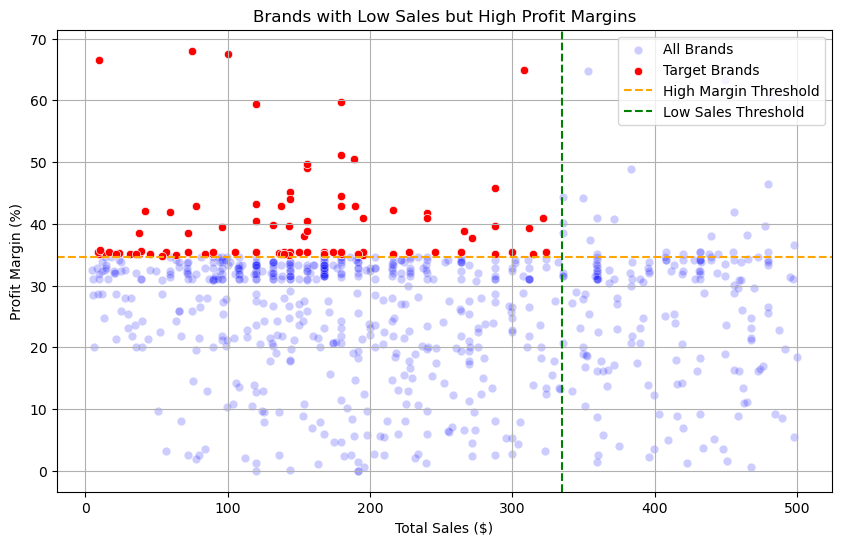

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data = better_view_filter1, x = 'TotalSalesDollars', y = "ProfitMargin", color = "blue", label = "All Brands", alpha = 0.2)
sns.scatterplot(data = target_brands, x = 'TotalSalesDollars', y = "ProfitMargin", color = "red", label = "Target Brands")

plt.axhline(high_profit_threshold, linestyle ="--", color = "orange", label = "High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle = "--", color = "green", label = "Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands with Low Sales but High Profit Margins")
plt.legend()
plt.grid(True)
plt.show()

<strong> Identify Brands which exhibit higher sales performance but lower profit margins.

In [19]:
high_sales_threshold = brand_performance["TotalSalesDollars"].quantile(0.85)
low_profit_threshold =  0 #brand_performance["ProfitMargin" ].quantile(0.15)

In [20]:
high_sales_threshold

np.float64(69897.12350000002)

In [21]:
low_profit_threshold 

0

In [22]:
# Filtering brands with high sales value but lower profit margins

target_brands2 = brand_performance[
    (brand_performance["TotalSalesDollars"] >= high_sales_threshold) &
    (brand_performance["ProfitMargin"] <= low_profit_threshold)
]

print("Brands with High Sales but Low Profit Margins: \n")

display(target_brands2.sort_values(by='TotalSalesDollars'))
print(f"{target_brands2.shape[0]} rows, {target_brands2.shape[1]} columns\n")

Brands with High Sales but Low Profit Margins: 



,Description,TotalSalesDollars,ProfitMargin
4523,Rocky Peak Hard Cinnamon,72075.00,-2.56
4449,Remy Martin 1738 Accord Royl,72486.63,-13.23
5130,Tanteo Jalapeno Tequila,80547.53,-18.22
4028,OuterSpace Vodka,81795.02,-15.12
2780,Jack Daniels Barrel Proof,89296.41,-5.08
2063,Fernet-Branca Italian Liquer,90170.16,-11.39
4965,St Remy VSOP Authentic Brndy,94103.99,-29.21
2028,Fabrizia's Margarita RTD,94406.84,-2.66
1385,Clase Azul Reposado Tequila,95499.46,-17.39
395,Banfi Rosa Regale,96923.38,-5.89


21 rows, 3 columns



In [23]:
better_view_filter2 = brand_performance[(brand_performance["TotalSalesDollars"] > 60000) & (brand_performance["ProfitMargin"] < 10)] # for better and clear visualization

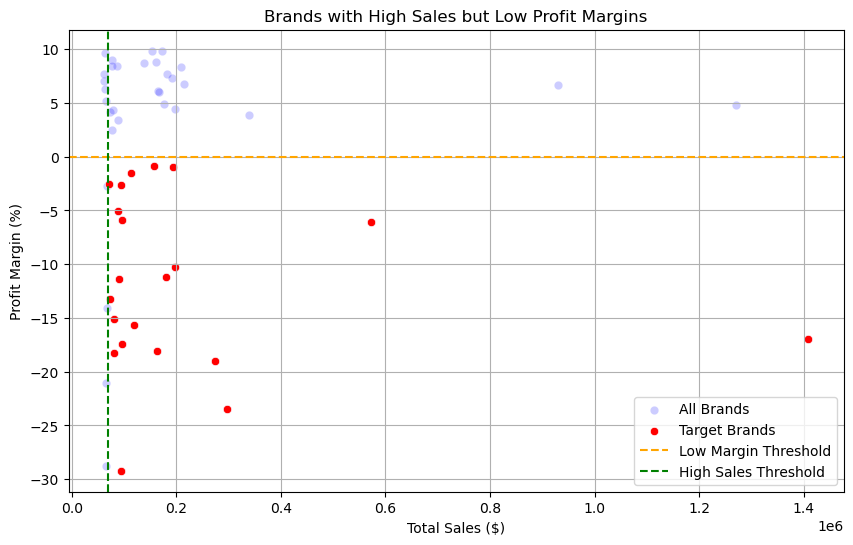

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data = better_view_filter2, x = 'TotalSalesDollars', y = "ProfitMargin", color = "blue", label = "All Brands", alpha = 0.2)
sns.scatterplot(data = target_brands2, x = 'TotalSalesDollars', y = "ProfitMargin", color = "red", label = "Target Brands")

plt.axhline(low_profit_threshold, linestyle ="--", color = "orange", label = "Low Margin Threshold")
plt.axvline(high_sales_threshold, linestyle = "--", color = "green", label = "High Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands with High Sales but Low Profit Margins")
plt.legend()
plt.grid(True)
plt.show()

<strong> Which Vendors and Brands demonstrate highest sales performance ?

In [25]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [26]:
# Top vendors and Brands Sales Performance
top_vendors = df_2.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df_2.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors.apply(format_dollars)

VendorName
DIAGEO NORTH AMERICA INC      50.36M
MARTIGNETTI COMPANIES         28.84M
PERNOD RICARD USA             28.30M
JIM BEAM BRANDS COMPANY       25.98M
CONSTELLATION BRANDS INC      19.66M
BROWN-FORMAN CORP             14.50M
E & J GALLO WINERY            13.32M
ULTRA BEVERAGE COMPANY LLP    12.73M
BACARDI USA INC               12.35M
SAZERAC CO INC                10.61M
Name: TotalSalesDollars, dtype: object

In [27]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    6.63M
Absolut 80 Proof           6.24M
Tito's Handmade Vodka      6.04M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Capt Morgan Spiced Rum     4.74M
Grey Goose Vodka           3.83M
Tanqueray                  3.02M
Patron Silver Tequila      2.84M
Jim Beam                   2.84M
Name: TotalSalesDollars, dtype: object

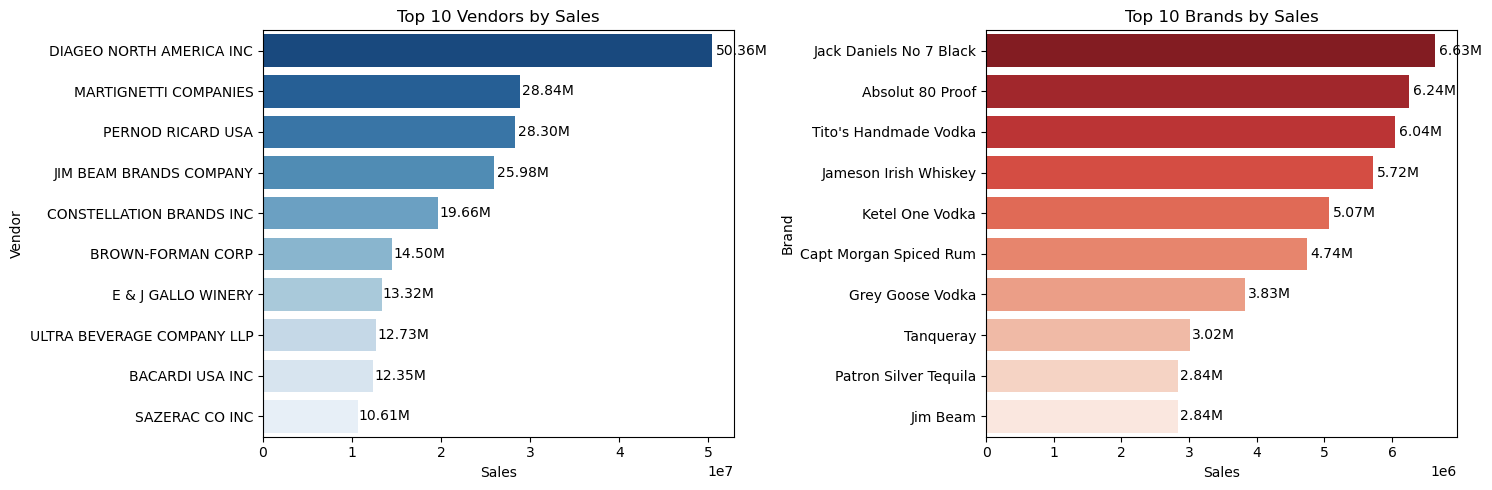

In [28]:
plt.figure(figsize=(15, 5))

# top 10 vendors by sales
plt.subplot(1, 2, 1)

ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")

plt.title("Top 10 Vendors by Sales")
plt.xlabel("Sales")
plt.ylabel("Vendor")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + 0.01 * bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        va="center",
        ha="left"
    )


# top 10 brands by sales
plt.subplot(1, 2, 2)

ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")

plt.title("Top 10 Brands by Sales")
plt.xlabel("Sales")
plt.ylabel("Brand")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + 0.01 * bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

<strong> Which Vendors and Brands demonstrate lowest sales performance ?

In [29]:
bottom_vendors = df_2.groupby("VendorName")["TotalSalesDollars"].sum().nsmallest(10)
bottom_brands = df_2.groupby("Description")["TotalSalesDollars"].sum().nsmallest(10)
bottom_vendors.apply(format_dollars)

VendorName
UNCORKED                       475.71
HIGHLAND WINE MERCHANTS LLC     1.39K
APPOLO VINEYARDS LLC            1.62K
AMERICAN SPIRITS EXCHANGE       1.72K
R.P.IMPORTS INC                 1.81K
BLACK PRINCE DISTILLERY INC     1.98K
BLACK ROCK SPIRITS LLC          2.05K
MILTONS DISTRIBUTING CO         2.21K
BRONCO WINE COMPANY             2.39K
THE PIERPONT GROUP LLC          2.75K
Name: TotalSalesDollars, dtype: object

In [30]:
bottom_brands.apply(format_dollars)

Description
Terruzzi & Puthod Vernaccia     4.99
Albero Sparkling Wh Organic     5.79
Firefly Ridge Chard             5.79
Allen's Blue Curacao Liqueur    5.99
Kirkland Signature Supr Brdx    7.99
Redtree Moscato                 8.99
Tijuana White Tequilla          8.99
Ch Lestiac Cotes de Bordeaux    9.49
Pacifico Sur Rsv Malbec         9.99
Santa Rita Organic Svgn Bl      9.99
Name: TotalSalesDollars, dtype: object

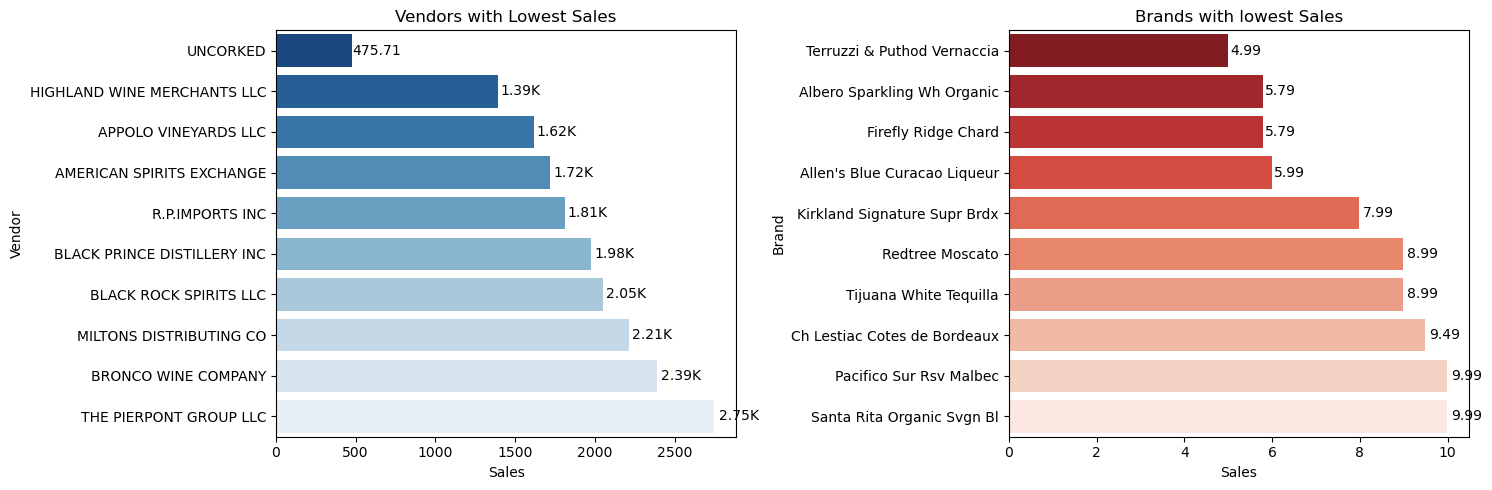

In [31]:
plt.figure(figsize=(15, 5))

#10 vendors with lowest sales
plt.subplot(1, 2, 1)

ax1 = sns.barplot(y=bottom_vendors.index, x=bottom_vendors.values, palette="Blues_r")

plt.title("Vendors with Lowest Sales")
plt.xlabel("Sales")
plt.ylabel("Vendor")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + 0.01 * bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        va="center",
        ha="left"
    )


# 10 brands with lowest sales
plt.subplot(1, 2, 2)

ax2 = sns.barplot(y=bottom_brands.index.astype(str), x=bottom_brands.values, palette="Reds_r")

plt.title("Brands with lowest Sales")
plt.xlabel("Sales")
plt.ylabel("Brand")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + 0.01 * bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

<strong> Which Vendors contribute the most to total purchase dollars ?

In [32]:
vendor_performance = df_2.groupby('VendorName').agg({"TotalPurchaseDollars" : "sum", "GrossProfit" : "sum", "TotalSalesDollars" : "sum"}).reset_index()
vendor_performance.shape

(116, 4)

In [33]:
vendor_performance["PurchaseContribution%"] = vendor_performance["TotalPurchaseDollars"]/ vendor_performance["TotalPurchaseDollars"].sum()*100

In [34]:
vendor_performance = vendor_performance.sort_values("PurchaseContribution%", ascending = False)

In [35]:
# Display top 10 vendors from whome the business purchases the most

top_vendors = vendor_performance.head(10)
top_vendors["TotalSalesDollars"] = top_vendors["TotalSalesDollars"].apply(format_dollars)
top_vendors["TotalPurchaseDollars"] = top_vendors["TotalPurchaseDollars"].apply(format_dollars)
top_vendors["GrossProfit"] = top_vendors["GrossProfit"].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,38.31M,12.06M,50.36M,15.57
66,PERNOD RICARD USA,21.38M,6.92M,28.30M,8.69
55,MARTIGNETTI COMPANIES,20.73M,8.10M,28.84M,8.43
44,JIM BEAM BRANDS COMPANY,20.04M,5.94M,25.98M,8.15
20,CONSTELLATION BRANDS INC,12.75M,6.92M,19.66M,5.18
12,BROWN-FORMAN CORP,10.87M,3.63M,14.50M,4.42
103,ULTRA BEVERAGE COMPANY LLP,9.91M,2.82M,12.73M,4.03
30,E & J GALLO WINERY,9.06M,4.26M,13.32M,3.68
7,BACARDI USA INC,9.03M,3.31M,12.35M,3.67
77,SAZERAC CO INC,8.05M,2.56M,10.61M,3.27


In [36]:
top_vendors["PurchaseContribution%"].sum()

np.float64(65.10313934466065)

In [37]:
top_vendors["Cumulative_Contribution"] = top_vendors["PurchaseContribution%"].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution
25,DIAGEO NORTH AMERICA INC,38.31M,12.06M,50.36M,15.57,15.57
66,PERNOD RICARD USA,21.38M,6.92M,28.30M,8.69,24.27
55,MARTIGNETTI COMPANIES,20.73M,8.10M,28.84M,8.43,32.70
44,JIM BEAM BRANDS COMPANY,20.04M,5.94M,25.98M,8.15,40.84
20,CONSTELLATION BRANDS INC,12.75M,6.92M,19.66M,5.18,46.03
12,BROWN-FORMAN CORP,10.87M,3.63M,14.50M,4.42,50.44
103,ULTRA BEVERAGE COMPANY LLP,9.91M,2.82M,12.73M,4.03,54.48
30,E & J GALLO WINERY,9.06M,4.26M,13.32M,3.68,58.16
7,BACARDI USA INC,9.03M,3.31M,12.35M,3.67,61.83
77,SAZERAC CO INC,8.05M,2.56M,10.61M,3.27,65.10


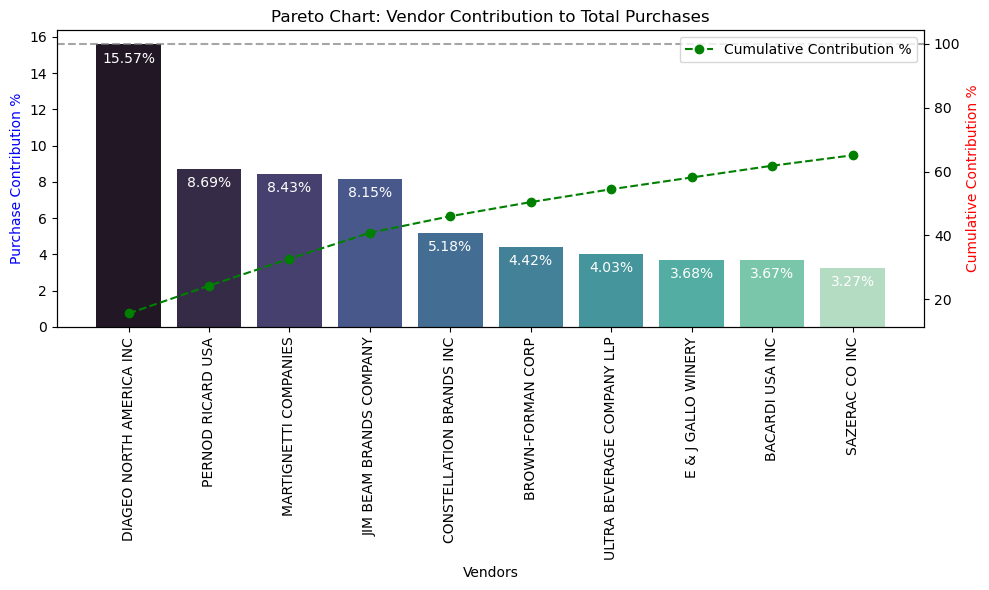

In [38]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(x=top_vendors["VendorName"], y=top_vendors["PurchaseContribution%"], palette="mako", ax=ax1)

# Add values on bars
for i, val in enumerate(top_vendors["PurchaseContribution%"]):
    ax1.text(
        i,
        val - 1,
        str(round(val, 2)) + '%',
        ha="center",
        fontsize=10,
        color="white"
    )

# Line plot for Cumulative Contribution %
ax2 = ax1.twinx()

ax2.plot( top_vendors["VendorName"], top_vendors["Cumulative_Contribution"], color="green", marker="o", linestyle="dashed", label="Cumulative Contribution %")

ax1.set_xticklabels(top_vendors["VendorName"], rotation=90)

ax1.set_ylabel("Purchase Contribution %", color="blue")

ax2.set_ylabel( "Cumulative Contribution %",color="red")

ax1.set_xlabel("Vendors")

ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchases")

ax2.axhline(y=100, color="gray", linestyle="dashed", alpha=0.7)

ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

<strong> What percentage of our purchases comes from our top vendors?

In [39]:
print(f"Total Purchase Contribution of top 10 vendors is {top_vendors["PurchaseContribution%"].sum().round(2)}%")

Total Purchase Contribution of top 10 vendors is 65.1%


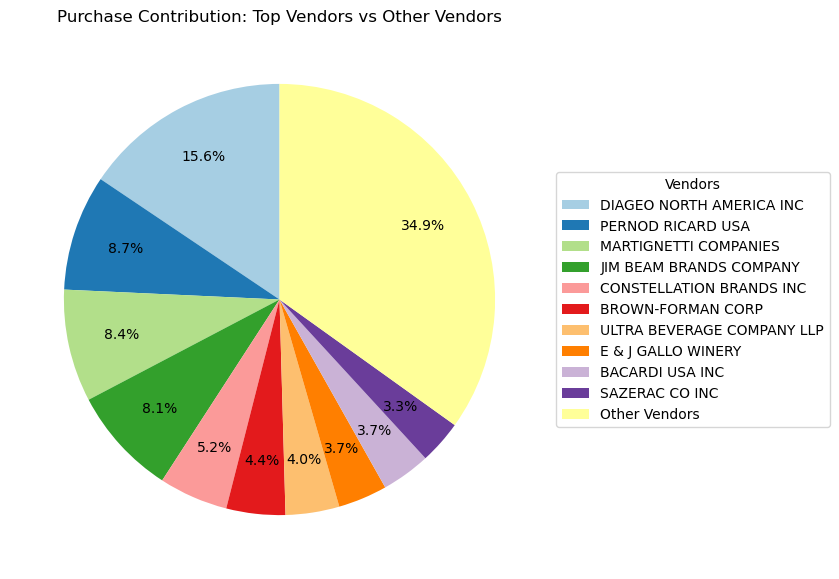

In [40]:
vendors = list(top_vendors["VendorName"].values)
purchase_contributions = list(top_vendors["PurchaseContribution%"].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# appending value of other vendors and remaining contribution
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Creating the pie chart

plt.figure(figsize=(10, 7))

colors = sns.color_palette("Paired", len(vendors))

plt.pie(purchase_contributions, autopct="%1.1f%%", startangle=90, pctdistance=0.75, colors=colors)

plt.title("Purchase Contribution: Top Vendors vs Other Vendors")

# Adding legend
plt.legend(
    vendors,
    title="Vendors",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.show()

<strong> Does purchasing in bulk reduces the unit price, and what is the optimal purchase volumne for cost saving ?

In [41]:
df_2["UnitPurchasePrice"] = df_2["TotalPurchaseDollars"]/df_2["TotalPurchaseQuantity"]

In [42]:
df_2["OrderSize"] = pd.qcut(df_2["TotalPurchaseQuantity"], q = 3, labels = ["Small", "Medium", "Large"])

In [43]:
df_2[["TotalPurchaseQuantity", "OrderSize"]]

,TotalPurchaseQuantity,OrderSize
0,145080,Large
1,164038,Large
2,187407,Large
3,201682,Large
4,138109,Large
...,...,...
6318,1,Small
6319,1,Small
6320,1,Small
6321,1,Small


In [44]:
df_2.groupby("OrderSize")["UnitPurchasePrice"].mean()

OrderSize
Small    32.01
Medium   17.37
Large    11.18
Name: UnitPurchasePrice, dtype: float64

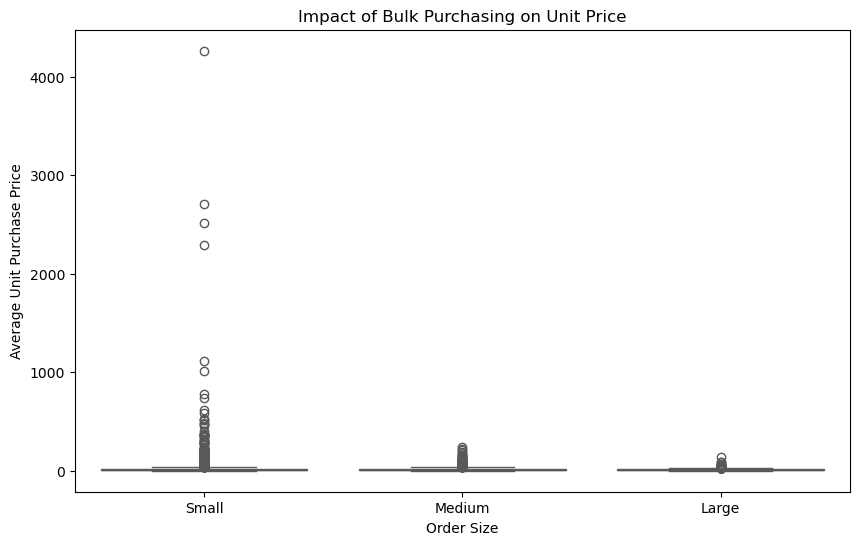

In [45]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df_2, x = "OrderSize", y = "UnitPurchasePrice", palette = "Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Buying products in bulk (Large Order Size) from vendors leads to lowest unit price ($11.18 per unit), meaning higher margins if business can manage inventory efficiently.

- Larger order sizes result in lower per-unit purchase costs, indicating that bulk purchasing allows the business to achieve better pricing from vendors.

<strong> which vendors products leads to low inventory turnover, indicating excess stock and slow-moving products ?

In [46]:
print("Top 10 vendors with the lowest Stock Turnover : \n")
display(df_2[df_2["StockTurnover"] < 1].groupby("VendorName")[['StockTurnover']].mean().sort_values("StockTurnover", ascending = True).head(10).reset_index())
print()

Top 10 vendors with the lowest Stock Turnover : 



,VendorName,StockTurnover
0,UNCORKED,0.36
1,VINEYARD BRANDS LLC,0.44
2,Russian Standard Vodka,0.45
3,GILMANTON WINERY & VINEYARD,0.47
4,APPOLO VINEYARDS LLC,0.47
5,Serralles Usa LLC,0.53
6,SOUTHERN GLAZERS W&S OF NE,0.60
7,NICHE W & S,0.61
8,HIGHLAND WINE MERCHANTS LLC,0.61
9,ALISA CARR BEVERAGES,0.63


<strong>How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it ? 

In [47]:
df_2["UnsoldInventoryValue"] = (df_2["TotalPurchaseQuantity"] - df_2["TotalSalesQuantity"]) * df_2["PurchasePrice"]
print(f"Total Unsold Capital : {format_dollars(df_2["UnsoldInventoryValue"].sum())}")

Total Unsold Capital : 13.21M


In [48]:
# aggregating Unsold Capital Locked per Vendor
inventory_value_per_vendor = df_2.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#sort vendors based on highest Unsold Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by = "UnsoldInventoryValue", ascending = False)
inventory_value_per_vendor["UnsoldInventoryContribution%"] = inventory_value_per_vendor["UnsoldInventoryValue"]/inventory_value_per_vendor["UnsoldInventoryValue"].sum() * 100
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
print("Top 10 vendors with the highest Unsold Inventory Value: \n")
display(inventory_value_per_vendor.head(10))
print()
print(f"The vendor {inventory_value_per_vendor["VendorName"].iloc[0]} holds the highest Unsold Inventory Value of ${inventory_value_per_vendor["UnsoldInventoryValue"].iloc[0]}, contributing {inventory_value_per_vendor["UnsoldInventoryContribution%"].iloc[0].round(2)}% to the total Unsold Inventory Value of ${format_dollars(df_2["UnsoldInventoryValue"].sum())}.\n\n")

Top 10 vendors with the highest Unsold Inventory Value: 



,VendorName,UnsoldInventoryValue,UnsoldInventoryContribution%
25,DIAGEO NORTH AMERICA INC,1.60M,12.09
55,MARTIGNETTI COMPANIES,1.53M,11.58
44,JIM BEAM BRANDS COMPANY,1.02M,7.74
103,ULTRA BEVERAGE COMPANY LLP,1.00M,7.58
66,PERNOD RICARD USA,708.17K,5.36
65,PERFECTA WINES,627.36K,4.75
51,M S WALKER INC,529.60K,4.01
113,WILLIAM GRANT & SONS INC,492.70K,3.73
30,E & J GALLO WINERY,458.33K,3.47
20,CONSTELLATION BRANDS INC,431.59K,3.27



The vendor DIAGEO NORTH AMERICA INC holds the highest Unsold Inventory Value of $1.60M, contributing 12.09% to the total Unsold Inventory Value of $13.21M.




<strong> What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors ? 

In [49]:
top_threshold = df_2["TotalSalesDollars"].quantile(0.75)
bottom_threshold = df_2["TotalSalesDollars"].quantile(0.25)
print(f"Top_threshold : {top_threshold.round(2)} and Bottom_threshold : {bottom_threshold.round(2)}")
print()

Top_threshold : 40200.84 and Bottom_threshold : 819.14



In [50]:
top_vendors = df_2[df_2["TotalSalesDollars"] >= top_threshold][["VendorName", "TotalSalesDollars", "ProfitMargin"]]
bottom_vendors = df_2[df_2["TotalSalesDollars"] <= bottom_threshold][["VendorName", "TotalSalesDollars", "ProfitMargin"]]

In [51]:
print("Top Vendors : \n")
display(top_vendors)
print("\nBottom Vendors : \n")
display(bottom_vendors)
print()

Top Vendors : 



,VendorName,TotalSalesDollars,ProfitMargin
0,BROWN-FORMAN CORP,5101919.51,25.30
1,MARTIGNETTI COMPANIES,4819073.49,21.06
2,PERNOD RICARD USA,4538120.60,24.68
3,DIAGEO NORTH AMERICA INC,4475972.88,27.14
4,DIAGEO NORTH AMERICA INC,4223107.62,28.41
...,...,...,...
1807,CONSTELLATION BRANDS INC,42736.36,42.55
1815,PINE STATE TRADING CO,40901.58,40.40
1817,E & J GALLO WINERY,40557.84,39.93
1818,BANFI PRODUCTS CORP,40750.56,40.22



Bottom Vendors : 



,VendorName,TotalSalesDollars,ProfitMargin
4257,ULTRA BEVERAGE COMPANY LLP,781.83,-82.80
4265,PERFECTA WINES,818.91,-73.15
4271,STATE WINE & SPIRITS,775.89,-81.36
4320,PERFECTA WINES,815.83,-60.42
4356,APPOLO VINEYARDS LLC,715.52,-74.42
...,...,...,...
6318,WINE GROUP INC,5.79,31.09
6319,STE MICHELLE WINE ESTATES,5.29,32.51
6320,MARTIGNETTI COMPANIES,4.99,32.46
6321,PALM BAY INTERNATIONAL INC,9.99,66.47


In [52]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (26.87, 27.95), Mean: 27.41
Bottom Vendors 95% CI: (5.40, 8.74), Mean: 7.07


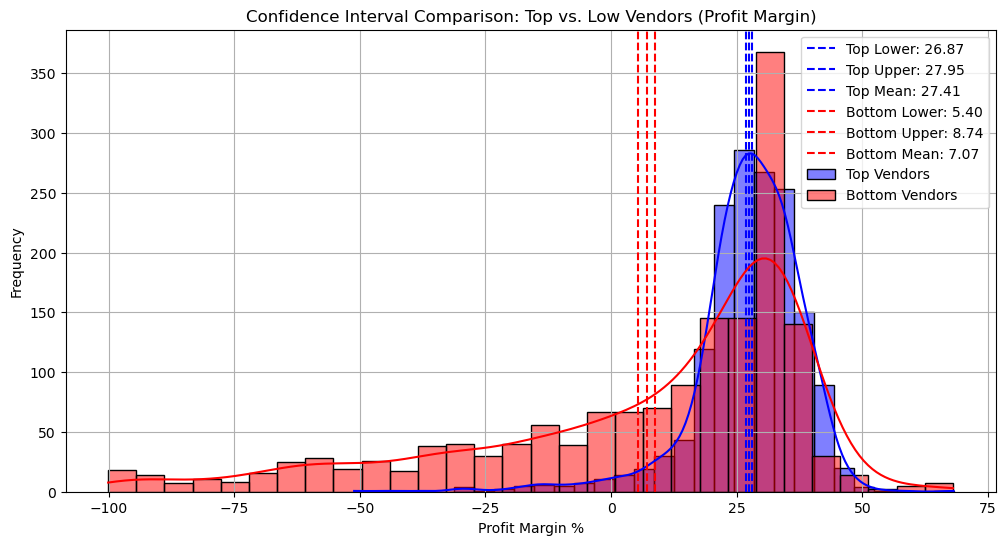

In [53]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors["ProfitMargin"])
bottom_mean, bottom_lower, bottom_upper = confidence_interval(bottom_vendors["ProfitMargin"])

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Bottom Vendors 95% CI: ({bottom_lower:.2f}, {bottom_upper:.2f}), Mean: {bottom_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors["ProfitMargin"], kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")

plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")

plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")

plt.axvline( top_mean, color="blue", linestyle="--", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(bottom_vendors["ProfitMargin"], kde=True, color="red", bins=30, alpha=0.5, label="Bottom Vendors")

plt.axvline(bottom_lower, color="red", linestyle="--", label=f"Bottom Lower: {bottom_lower:.2f}")

plt.axvline(bottom_upper, color="red", linestyle="--", label=f"Bottom Upper: {bottom_upper:.2f}")

plt.axvline(bottom_mean, color="red", linestyle="--", label=f"Bottom Mean: {bottom_mean:.2f}")


# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin %")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors (5.40% to 8.74%) is significantly lower than that of top-performing vendors (26.87% to 27.95%).
- This suggests that sales from low performing vendors may generate low profit margins due to their lower sales volumes, indicating that sales volume leads to higher profitability.
- For High-Performing vendors: We can try to implement some discounts or marketing campaigns to uplift the sales for their products more, which could result in higher Gross Profit as correlation between TotalSalesDollars and GrossProfit is 0.98.
- For Low-Performing vendors: These vendors have low profit margins, because of their lower sales. This could be because of customer interests, quality issues or due to some other factors, the responsible team should investigate into this.

<strong>Is there a significant difference in profit margins between top-performing and low-performing vendors ?

Hypothesis:

Null Hypothesis : There is no significance difference in the mean profit margins of top-performing and low-performing vendors.

Alternate Hypothesis : The mean profit margins of top-performing and low-performing vendors are significantly different.

In [54]:
top_threshold = df_2["TotalSalesDollars"].quantile(0.75)
bottom_threshold = df_2["TotalSalesDollars"].quantile(0.25)

top_vendors = df_2[df_2["TotalSalesDollars"] >= top_threshold][["VendorName", "TotalSalesDollars", "ProfitMargin"]]
bottom_vendors = df_2[df_2["TotalSalesDollars"] <= bottom_threshold][["VendorName", "TotalSalesDollars", "ProfitMargin"]]

# Perform Two Sample T-Test

t_stats, p_value = ttest_ind(top_vendors["ProfitMargin"], bottom_vendors["ProfitMargin"], equal_var = False)

print(f"T-Statistics: {t_stats:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("There is a significant difference in profit margins between top performing vendors and low performing vendors : Reject Null Hypothesis.")
else:
    print("No significant difference in profit margins between top performing vendors and low performing vendors : Reject Alternate Hypothesis.")

T-Statistics: 22.7266, P-Value: 0.0000
There is a significant difference in profit margins between top performing vendors and low performing vendors : Reject Null Hypothesis.


In [55]:
df_2.shape

(6323, 21)

In [56]:
df_2.to_csv(r"D:\Data Analysis Capstone Projects\Vendor Performance Data Analysis-13-08-26\data\final_vendor_performance_summary.csv", index = False)